# Homework 1 — Tokenizer pruning for one natural language: **caveman English**

**Ilia Mikhalchuk** · Modern Methods and Algorithms of Generative AI · Skoltech, Fall 2026 · repo: [github.com/miilv/prune-to-caveman](https://github.com/miilv/prune-to-caveman)

**Language.** *Caveman English*: a closed-vocabulary register of English. All words are lowercase base forms from
Basic English 850 plus 111 caveman words (961 types in total, no *a*/*the*, no inflections); ~140 frequent proper names stay
Capitalized; digits and `. , ? !` are the only other symbols. Example: *"mammoth be big animal with long hair. people hunt it with spear long ago."*

**Corpus.** 3,000+ English Wikipedia articles (`wikimedia/wikipedia` `20231101.en`, CC BY-SA 4.0) on history, nature,
places, science, myth and crafts, rewritten paragraph by paragraph into caveman English by `claude-haiku-5-5`. Every
output is checked word by word against the closed vocabulary (one repair round, then a replacement dictionary, then
sentences that still break the rules are dropped). The split into train / held-out is **by article** and was fixed
before generation. The generation pipeline lives in `corpus_pipeline/` of the repo; this notebook only downloads the
frozen corpus and never calls an LLM API.

**Model.** `Qwen/Qwen2.5-0.5B` (byte-level BPE, 151,643 + 22 tokens, tied embeddings).

Runs top to bottom on a Colab T4 or any CUDA GPU (timings are printed per part); `BONUS = False` skips B1/B3/B4.

In [1]:
import importlib.util, subprocess, sys
if "google.colab" in sys.modules or importlib.util.find_spec("tiktoken") is None:   # Colab: transformers >= 5 (dtype=), tiktoken
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5", "tokenizers", "tiktoken"], check=True)
import os, json, math, time, random, collections, re, urllib.request, shutil, copy, platform
import numpy as np, pandas as pd, torch, torch.nn.functional as F, matplotlib.pyplot as plt
import tokenizers, transformers, tiktoken
from tokenizers import Tokenizer, models, trainers
from transformers import AutoModelForCausalLM, PreTrainedTokenizerFast
from huggingface_hub import snapshot_download

MODEL = "Qwen/Qwen2.5-0.5B"
SEED = 0
BONUS = True                       # B1 (vocabulary extension), B3 (random-init baseline), B4 (serving)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# bf16 on Ampere+ GPUs, fp16 on a T4 (no bf16 tensor cores; on the 4090 fp16 gives the same bits/byte as bf16 to 4
# decimals), float32 on CPU. Cross-entropy is always computed in float32.
DTYPE = (torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16) if DEVICE == "cuda" else torch.float32
CORPUS_URL = "https://raw.githubusercontent.com/miilv/prune-to-caveman/main/corpus/"

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
seed_all()
os.makedirs("figures", exist_ok=True)
RESULTS, TIMES, T_START = {}, {}, time.time()
_t = [time.time()]
def lap(name):
    TIMES[name] = round(time.time() - _t[0], 1); _t[0] = time.time()
    print(f"[{name}: {TIMES[name]:.0f} s, total {time.time() - T_START:.0f} s]")

print("device:", DEVICE, torch.cuda.get_device_name() if DEVICE == "cuda" else platform.processor(),
      "| python", platform.python_version(), "| torch", torch.__version__, "| transformers", transformers.__version__,
      "| tokenizers", tokenizers.__version__, "| tiktoken", tiktoken.__version__)

/root/hw1-tokenizer-pruning/.venv-nb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda NVIDIA GeForce RTX 4090 | python 3.12.15 | torch 2.14.1+cu130 | transformers 5.19.0 | tokenizers 0.23.2 | tiktoken 0.14.0


## Helpers
The first cell is the starter code (`tokpruning.py` from the seminar) unchanged. The second cell adds what this notebook
needs on top: a **batched** bits-per-byte (same windows and the same number as the starter's function, checked below),
a batched agreement check, remapping of special-token ids in the model config, the merge-closure of a token set, and
checkpoint size on disk.

In [2]:
# --------------------------------------------------------------------------- inspection
def load_tokenizer_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def merges_as_pairs(model_json):
    """tokenizer.json stores merges either as "a b" strings (old) or as [a, b] lists (new)."""
    out = []
    for m in model_json["merges"]:
        if isinstance(m, str):
            a, b = m.split(" ", 1)
        else:
            a, b = m
        out.append((a, b))
    return out


def token_usage(tok: Tokenizer, texts, batch_size=256):
    """Count how often every vocabulary id appears when tokenizing `texts` (an iterable of str)."""
    counts = collections.Counter()
    n_tokens = 0
    n_bytes = 0
    batch = []
    for t in texts:
        batch.append(t)
        n_bytes += len(t.encode("utf-8"))
        if len(batch) == batch_size:
            for enc in tok.encode_batch(batch):
                counts.update(enc.ids); n_tokens += len(enc.ids)
            batch = []
    if batch:
        for enc in tok.encode_batch(batch):
            counts.update(enc.ids); n_tokens += len(enc.ids)
    return counts, n_tokens, n_bytes


# --------------------------------------------------------------------------- pruning
def prune_bpe_tokenizer(tok_json, keep_ids, verbose=True):
    """Return (new_tok_json, old2new) where the vocabulary is restricted to `keep_ids`
    plus everything needed to keep the BPE merges consistent:
      * all added/special tokens,
      * the base alphabet (all tokens that are not produced by any merge, e.g. the 256 byte-level chars),
      * the transitive closure of merge inputs of every kept token.
    Ids are renumbered contiguously in the order of the original ids."""
    model = tok_json["model"]
    assert model["type"] == "BPE", "this helper handles BPE tokenizers only"
    vocab = model["vocab"]                      # token string -> id
    id2tok = {i: t for t, i in vocab.items()}
    pairs = merges_as_pairs(model)
    produced = {a + b: (a, b) for a, b in pairs}   # merge result -> its two inputs

    keep = set(int(i) for i in keep_ids)
    # 1) added / special tokens
    added = tok_json.get("added_tokens", [])
    for at in added:
        keep.add(at["id"])
    # 2) base alphabet = vocab entries that no merge produces
    for t, i in vocab.items():
        if t not in produced:
            keep.add(i)
    # 3) closure over merge inputs
    stack = [id2tok[i] for i in keep if i in id2tok]
    seen = set(stack)
    while stack:
        t = stack.pop()
        if t in produced:
            for part in produced[t]:
                if part not in seen:
                    seen.add(part); stack.append(part)
                    keep.add(vocab[part])
    # 4) renumber
    old_ids_sorted = sorted(i for i in keep if i in id2tok)
    old2new = {old: new for new, old in enumerate(old_ids_sorted)}
    new_vocab = {id2tok[old]: new for old, new in old2new.items()}
    new_merges = []
    for a, b in pairs:
        if (a + b) in new_vocab and a in new_vocab and b in new_vocab:
            new_merges.append([a, b] if not isinstance(model["merges"][0], str) else f"{a} {b}")
    new_json = json.loads(json.dumps(tok_json))   # deep copy
    new_json["model"]["vocab"] = new_vocab
    new_json["model"]["merges"] = new_merges
    # added tokens that live outside `vocab` (ids >= len(vocab)) get fresh ids after the vocab
    next_id = len(new_vocab)
    new_added = []
    for at in sorted(added, key=lambda a: a["id"]):
        at = dict(at)
        if at["content"] in new_vocab:
            at["id"] = new_vocab[at["content"]]
        else:
            old2new[at["id"]] = next_id
            at["id"] = next_id; next_id += 1
        new_added.append(at)
    new_json["added_tokens"] = new_added
    # post-processor templates may reference special-token ids (e.g. BOS) -> remap
    _remap_ids_in_post_processor(new_json.get("post_processor"), old2new)
    if verbose:
        print(f"vocab {len(vocab):,} -> {len(new_vocab):,} tokens; merges {len(pairs):,} -> {len(new_merges):,}; "
              f"added tokens {len(added)}; total ids {next_id:,}")
    return new_json, old2new


def _remap_ids_in_post_processor(pp, old2new):
    if pp is None:
        return
    if isinstance(pp, dict):
        if "special_tokens" in pp and isinstance(pp["special_tokens"], dict):
            for st in pp["special_tokens"].values():
                if "ids" in st:
                    st["ids"] = [old2new.get(i, i) for i in st["ids"]]
        for v in pp.values():
            _remap_ids_in_post_processor(v, old2new)
    elif isinstance(pp, list):
        for v in pp:
            _remap_ids_in_post_processor(v, old2new)


def tokenizer_from_json(tok_json):
    return Tokenizer.from_str(json.dumps(tok_json))


# --------------------------------------------------------------------------- model surgery
def prune_model_embeddings(model, old2new, pad_to_multiple_of=64):
    """Slice the (tied) input embedding / lm_head rows according to old2new. Returns the model."""
    new_size = max(old2new.values()) + 1
    padded = int(math.ceil(new_size / pad_to_multiple_of) * pad_to_multiple_of)
    emb = model.get_input_embeddings()
    old_w = emb.weight.data
    index = torch.tensor([old for old, new in sorted(old2new.items(), key=lambda kv: kv[1])], dtype=torch.long)
    new_w = old_w.new_zeros((padded, old_w.shape[1]))
    new_w[:new_size] = old_w[index]
    new_emb = torch.nn.Embedding(padded, old_w.shape[1], padding_idx=emb.padding_idx if emb.padding_idx is not None and emb.padding_idx < padded else None)
    new_emb.weight.data = new_w
    model.set_input_embeddings(new_emb)
    tied = getattr(model.config, "tie_word_embeddings", False)
    head = model.get_output_embeddings()
    if head is not None:
        if tied:
            head.weight = new_emb.weight
        else:
            old_h = head.weight.data
            new_h = old_h.new_zeros((padded, old_h.shape[1])); new_h[:new_size] = old_h[index]
            head.weight = torch.nn.Parameter(new_h)
            if head.bias is not None:
                nb = head.bias.data.new_zeros(padded); nb[:new_size] = head.bias.data[index]
                head.bias = torch.nn.Parameter(nb)
        head.out_features = padded
    model.config.vocab_size = padded
    return model


def n_params(model):
    return sum(p.numel() for p in model.parameters())


# --------------------------------------------------------------------------- evaluation
@torch.no_grad()
def bits_per_byte(model, tok: Tokenizer, texts, prefix_id=None, max_len=512, device="cpu"):
    """Cross-entropy of the model on `texts`, normalised per UTF-8 byte (tokenizer-independent).
    Every text is tokenized, prefixed with `prefix_id` (e.g. <|endoftext|>) so that every real token
    is predicted, and scored in windows of `max_len` tokens (no overlap)."""
    model.eval().to(device)
    total_nll, total_bytes, total_tokens = 0.0, 0, 0
    for text in texts:
        ids = tok.encode(text).ids
        total_bytes += len(text.encode("utf-8"))
        total_tokens += len(ids)
        if prefix_id is not None:
            ids = [prefix_id] + ids
        for s in range(0, len(ids) - 1, max_len - 1):
            chunk = ids[s:s + max_len]
            if len(chunk) < 2:
                break
            x = torch.tensor([chunk], device=device)
            logits = model(x).logits[0, :-1].float()
            nll = torch.nn.functional.cross_entropy(logits, x[0, 1:], reduction="sum")
            total_nll += nll.item()
    return {"bits_per_byte": total_nll / math.log(2) / total_bytes,
            "nll_per_token": total_nll / max(total_tokens, 1),
            "tokens": total_tokens, "bytes": total_bytes, "tokens_per_byte": total_tokens / total_bytes}


def tokenization_agreement(tok_a: Tokenizer, tok_b: Tokenizer, texts):
    """Fraction of texts whose token *strings* are identical under two tokenizers, and the
    average ratio of sequence lengths (b / a)."""
    same, ratio = 0, 0.0
    n = 0
    for t in texts:
        a = tok_a.encode(t); b = tok_b.encode(t)
        same += int(a.tokens == b.tokens)
        ratio += len(b.ids) / max(len(a.ids), 1)
        n += 1
    return {"identical_fraction": same / n, "length_ratio": ratio / n}

In [3]:
@torch.no_grad()
def bpb(model, tok, texts, prefix_id, max_len=512, device=DEVICE, logit_budget=2.5e8):
    """Exactly the starter's `bits_per_byte` (same prefix token, same non-overlapping windows of <= 512 tokens),
    but the windows of all texts are scored in batches with right padding. The batch size is chosen so that the
    float32 logits stay below `logit_budget` elements (the full 151k-vocab head needs small batches)."""
    model.eval().to(device)
    V = model.get_output_embeddings().weight.shape[0]
    bs = int(max(1, min(64, logit_budget // (max_len * V))))
    windows, n_tok, n_bytes = [], 0, 0
    for text, enc in zip(texts, tok.encode_batch(list(texts), add_special_tokens=False)):
        ids = [prefix_id] + enc.ids
        n_tok += len(enc.ids); n_bytes += len(text.encode("utf-8"))
        for s in range(0, len(ids) - 1, max_len - 1):
            if len(ids[s:s + max_len]) >= 2:
                windows.append(ids[s:s + max_len])
    windows.sort(key=len)
    nll = 0.0
    for i in range(0, len(windows), bs):
        b = windows[i:i + bs]; L = len(b[-1])
        x = torch.zeros(len(b), L, dtype=torch.long); mask = torch.zeros(len(b), L, dtype=torch.long)
        for j, w in enumerate(b):
            x[j, :len(w)] = torch.tensor(w); mask[j, :len(w)] = 1
        x, mask = x.to(device), mask.to(device)
        logits = model(input_ids=x, attention_mask=mask).logits[:, :-1].float()
        tgt = x[:, 1:].masked_fill(mask[:, 1:] == 0, -100)
        nll += F.cross_entropy(logits.reshape(-1, logits.shape[-1]), tgt.reshape(-1), ignore_index=-100,
                               reduction="sum").item()
    return {"bits_per_byte": nll / math.log(2) / n_bytes, "nll_per_token": nll / n_tok, "tokens": n_tok,
            "bytes": n_bytes, "tokens_per_byte": n_tok / n_bytes}


def agreement(tok_a, tok_b, texts):
    """Batched version of the starter's `tokenization_agreement` (same definition)."""
    texts = list(texts)
    A, B = tok_a.encode_batch(texts), tok_b.encode_batch(texts)
    same = [a.tokens == b.tokens for a, b in zip(A, B)]
    ratio = [len(b.ids) / max(len(a.ids), 1) for a, b in zip(A, B)]
    return {"identical_fraction": float(np.mean(same)), "length_ratio": float(np.mean(ratio))}


def remap_special_ids(model, old2new):
    """config / generation_config still hold the ORIGINAL ids of <|endoftext|> (bos = eos = 151643)."""
    for cfg in (model.config, model.generation_config):
        for k in ("bos_token_id", "eos_token_id", "pad_token_id"):
            v = getattr(cfg, k, None)
            if isinstance(v, int):
                setattr(cfg, k, old2new[v])
            elif isinstance(v, list):
                setattr(cfg, k, [old2new[i] for i in v])


def closure(tokens, produced, keep):
    """Merge inputs (recursively) of `tokens` that are not in `keep` yet."""
    out, stack = set(), list(tokens)
    while stack:
        t = stack.pop()
        for part in produced.get(t, ()):
            if part not in keep and part not in out:
                out.add(part); stack.append(part)
    return out


def dir_mb(d):
    return sum(os.path.getsize(os.path.join(d, f)) for f in os.listdir(d)) / 1e6


def load_model(p=None):
    return AutoModelForCausalLM.from_pretrained(p or path, dtype=DTYPE).to(DEVICE)

## Corpus
Downloaded from the repo (`corpus/`). Train and held-out are **different articles**; token usage is counted on train only.
`heldout_source_en.json` holds the original English Wikipedia text of the same held-out articles: it is never used for
pruning, only as an *out-of-language probe* (what does pruning cost on ordinary English?).

In [4]:
os.makedirs("corpus", exist_ok=True)
for fn in ["caveman_train.json", "caveman_heldout.json", "heldout_source_en.json", "stats.json"]:
    if not os.path.exists(f"corpus/{fn}"):
        urllib.request.urlretrieve(CORPUS_URL + fn, f"corpus/{fn}")
train_docs = json.load(open("corpus/caveman_train.json", encoding="utf-8"))
held_docs = json.load(open("corpus/caveman_heldout.json", encoding="utf-8"))
held_en = json.load(open("corpus/heldout_source_en.json", encoding="utf-8"))
corpus_stats = json.load(open("corpus/stats.json"))
en_probe = [d[:4000] for d in held_en[:60]]          # small fixed English probe (first 4,000 chars of 60 docs)
mb = lambda docs: sum(len(d.encode()) for d in docs) / 1e6
print(f"train   : {len(train_docs):,} articles, {mb(train_docs):.2f} MB, {sum(len(d.split()) for d in train_docs):,} words")
print(f"held-out: {len(held_docs):,} articles, {mb(held_docs)*1e3:.0f} KB  (English originals {mb(held_en)*1e3:.0f} KB, probe {mb(en_probe)*1e3:.0f} KB)")
words = collections.Counter(w for d in train_docs for w in re.findall(r"[A-Za-z]+", d))
print(f"word types in train: {len(words):,} ({sum(w.islower() for w in words)} lowercase list words, "
      f"{sum(not w.islower() for w in words)} names) | most common: {', '.join(w for w, _ in words.most_common(25))}")
i = 3
print("\n--- English original (held-out) ---\n" + held_en[i][:700] + "\n\n--- caveman ---\n" + held_docs[i][:700])
lap("corpus")

train   : 2,003 articles, 9.17 MB, 1,841,169 words
held-out: 182 articles, 793 KB  (English originals 1163 KB, probe 232 KB)


word types in train: 3,074 (957 lowercase list words, 2117 names) | most common: of, in, be, and, man, to, year, this, big, land, one, he, from, make, for, it, on, with, town, thing, old, part, have, many, other

--- English original (held-out) ---
Ujir Singh Thapa or Uzir Singh Thapa (), also known as Wazir Simha Thapa, anglicized as Wuzeer Singh, was Nepalese administrator and military officer. He was the son of Kaji Nain Singh Thapa, a nephew of the Mukhtiyar Bhimsen Thapa and elder brother of Mathabar Singh Thapa. His mother was Rana Kumari Pande, daughter of Mulkaji Ranajit Pande and granddaughter of Kaji Tularam Pande. During his late teenage, he was the military commander at the Palpa-Butwal axis during the Anglo-Nepalese War. He became the Governor (Bada Hakim) and the commander of armed forces deployed in Palpa administrative sector in 1814 AD on substitute of his grandfather Amar Singh Thapa (sanukaji) who died that year.

Uj

--- caveman ---
Ujir Singh Thapa be man of work a

## Part 1 — Token usage analysis

In [5]:
path = snapshot_download(MODEL, allow_patterns=["*.json", "*.safetensors"])
tok_json = load_tokenizer_json(os.path.join(path, "tokenizer.json"))
tok = Tokenizer.from_file(os.path.join(path, "tokenizer.json"))
V = len(tok_json["model"]["vocab"])
counts, n_tokens, n_bytes = token_usage(tok, train_docs)
n_words = sum(len(d.split()) for d in train_docs)
print(f"Qwen2.5 vocab {V:,} (+{len(tok_json['added_tokens'])} added) | tokens {n_tokens:,} | bytes/token {n_bytes/n_tokens:.2f} | "
      f"fertility {n_tokens/n_words:.3f} | distinct ids {len(counts):,} ({len(counts)/V:.2%} of the vocabulary)")

def tiktoken_counts(name, texts):
    enc = tiktoken.get_encoding(name)
    c = collections.Counter()
    for ids in enc.encode_ordinary_batch(texts):
        c.update(ids)
    return c, enc.n_vocab

usage = {"Qwen2.5 (151k)": (counts, V)}
for label, name in [("GPT-2 r50k (50k)", "r50k_base"), ("GPT-4 cl100k (100k)", "cl100k_base"), ("GPT-4o o200k (200k)", "o200k_base")]:
    usage[label] = tiktoken_counts(name, train_docs)

rows = []
for label, (c, vs) in usage.items():
    nt = sum(c.values())
    cum = np.cumsum(sorted(c.values(), reverse=True)) / nt
    rows.append({"tokenizer": label, "vocab": vs, "tokens": nt, "bytes/token": n_bytes / nt, "fertility": nt / n_words,
                 "distinct ids": len(c), "share of vocab": len(c) / vs,
                 "ids for 99% of occurrences": int(np.searchsorted(cum, 0.99) + 1)})
t1 = pd.DataFrame(rows).set_index("tokenizer")
display(t1.style.format({"bytes/token": "{:.2f}", "fertility": "{:.3f}", "share of vocab": "{:.2%}", "tokens": "{:,}",
                         "vocab": "{:,}", "distinct ids": "{:,}", "ids for 99% of occurrences": "{:,}"}))
RESULTS["part1"] = t1.reset_index().to_dict("records")

# same tokenizer, same articles: caveman vs the English originals (held-out side, never used for pruning)
c_cave, nt_c, nb_c = token_usage(tok, held_docs)
c_en, nt_e, nb_e = token_usage(tok, held_en)
print(f"held-out, Qwen2.5: caveman {nb_c/1e3:.0f} KB -> {len(c_cave):,} distinct ids, {nb_c/nt_c:.2f} bytes/token | "
      f"English originals {nb_e/1e3:.0f} KB -> {len(c_en):,} distinct ids, {nb_e/nt_e:.2f} bytes/token")
RESULTS["held_distinct"] = {"caveman": len(c_cave), "english": len(c_en)}

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 2727.41it/s]

Qwen2.5 vocab 151,643 (+22 added) | tokens 2,373,164 | bytes/token 3.87 | fertility 1.289 | distinct ids 4,973 (3.28% of the vocabulary)


,vocab,tokens,bytes/token,fertility,distinct ids,share of vocab,ids for 99% of occurrences
tokenizer,,,,,,,
Qwen2.5 (151k),"151,643","2,373,164",3.87,1.289,"4,973",3.28%,"1,918"
GPT-2 r50k (50k),"50,257","2,264,885",4.05,1.230,"5,995",11.93%,"2,474"
GPT-4 cl100k (100k),"100,277","2,269,439",4.04,1.233,"5,961",5.94%,"2,329"
GPT-4o o200k (200k),"200,019","2,264,949",4.05,1.230,"6,287",3.14%,"2,419"


held-out, Qwen2.5: caveman 793 KB -> 2,018 distinct ids, 3.84 bytes/token | English originals 1163 KB -> 21,867 distinct ids, 4.20 bytes/token


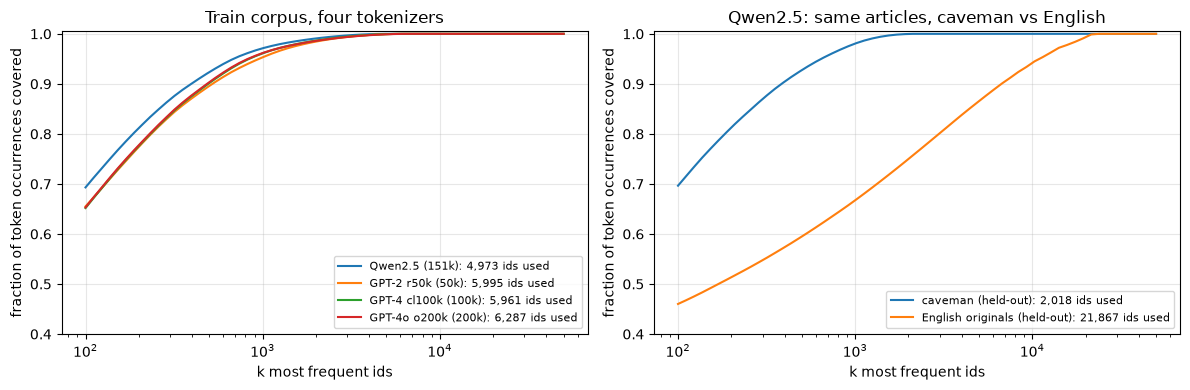

[part1: 2 s, total 2 s]


In [6]:
ks = np.unique(np.logspace(2, math.log10(50_000), 60).astype(int))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for label, (c, vs) in usage.items():
    cum = np.cumsum(sorted(c.values(), reverse=True)) / sum(c.values())
    ax[0].plot(ks, [cum[min(k, len(cum)) - 1] for k in ks], label=f"{label}: {len(c):,} ids used")
for label, c in [("caveman (held-out)", c_cave), ("English originals (held-out)", c_en)]:
    cum = np.cumsum(sorted(c.values(), reverse=True)) / sum(c.values())
    ax[1].plot(ks, [cum[min(k, len(cum)) - 1] for k in ks], label=f"{label}: {len(c):,} ids used")
for a, title in zip(ax, ["Train corpus, four tokenizers", "Qwen2.5: same articles, caveman vs English"]):
    a.set_xscale("log"); a.set_xlabel("k most frequent ids"); a.set_ylabel("fraction of token occurrences covered")
    a.set_title(title); a.grid(alpha=.3); a.legend(fontsize=8, loc="lower right"); a.set_ylim(0.4, 1.005)
plt.tight_layout(); plt.savefig("figures/coverage.png", dpi=150); plt.show()
lap("part1")

Caveman English is the extreme case of the seminar's observation: the whole train corpus uses about 3% of Qwen's 151k
ids, and about 2k ids cover 99% of all occurrences. The same articles in ordinary English need ten times more distinct
ids. The four tokenizers behave almost identically (fertility 1.23–1.29): all of them have every list word as a single
token with its leading space; the remaining tokens are punctuation, digits and pieces of rare names. Qwen is slightly
worse only because its pre-tokenizer splits every number into single digits, and caveman text is full of years
("year 1453"), while the GPT tokenizers keep up to three digits together (with the numbers removed, Qwen and cl100k
both give 1.172 tokens per word). A bigger vocabulary buys nothing for this
language — the extra ids are other scripts, code and rare English.

## Part 2 — Prune the tokenizer

In [7]:
M = 1
keep_ids = [i for i, c in counts.items() if c >= M]
new_json, old2new = prune_bpe_tokenizer(tok_json, keep_ids)
new_tok = tokenizer_from_json(new_json)

# 1) round trip on held-out text (and on ordinary English, which the pruned vocabulary was not built for)
rt_held = all(new_tok.decode(new_tok.encode(d).ids) == d for d in held_docs)
rt_en = all(new_tok.decode(new_tok.encode(d).ids) == d for d in held_en)
# 2) with M = 1 the whole train corpus must be tokenized identically
agree_train = agreement(tok, new_tok, train_docs)
# 3) held-out: identical documents and length ratio (pruned / original)
agree_held = agreement(tok, new_tok, held_docs)
held_paras = [p for d in held_docs for p in d.split("\n\n")]
agree_paras = agreement(tok, new_tok, held_paras)
agree_en = agreement(tok, new_tok, held_en)
assert rt_held and rt_en and agree_train["identical_fraction"] == 1.0
# 4) sizes before / after
n_merges = len(tok_json["model"]["merges"])
t2 = pd.DataFrame([
    {"": "original", "vocab": V, "merges": n_merges, "added tokens": len(tok_json["added_tokens"]), "total ids": V + len(tok_json["added_tokens"])},
    {"": f"pruned, m={M}", "vocab": len(new_json["model"]["vocab"]), "merges": len(new_json["model"]["merges"]),
     "added tokens": len(new_json["added_tokens"]), "total ids": new_tok.get_vocab_size(with_added_tokens=True)}]).set_index("")
display(t2)
print(f"1) decode(encode(x)) == x : caveman held-out {rt_held}, English originals {rt_en}")
print(f"2) train identical         : {agree_train['identical_fraction']:.0%} of {len(train_docs):,} articles, length ratio {agree_train['length_ratio']:.4f}")
print(f"3) held-out caveman        : identical {agree_held['identical_fraction']:.1%} of {len(held_docs)} articles, length ratio {agree_held['length_ratio']:.4f}")
print(f"   per paragraph           : identical {agree_paras['identical_fraction']:.1%} of {len(held_paras):,} paragraphs, length ratio {agree_paras['length_ratio']:.4f}")
print(f"   English originals       : identical {agree_en['identical_fraction']:.1%}, length ratio {agree_en['length_ratio']:.3f}")
RESULTS["part2"] = {"vocab": [V, len(new_json["model"]["vocab"])], "merges": [n_merges, len(new_json["model"]["merges"])],
                    "roundtrip": [rt_held, rt_en], "train": agree_train, "held": agree_held, "held_paragraphs": agree_paras, "english": agree_en}

# where the held-out text differs: tokens the train corpus never produced
diff = collections.Counter()
for a, b in zip(tok.encode_batch(held_docs), new_tok.encode_batch(held_docs)):
    if a.tokens != b.tokens:
        diff.update(t for t in a.tokens if t not in new_json["model"]["vocab"])
print("held-out tokens missing from the pruned vocabulary:", [(t.replace("Ġ", "␣"), n) for t, n in diff.most_common(15)])

vocab 151,643 -> 6,244 tokens; merges 151,387 -> 5,988; added tokens 22; total ids 6,266


,vocab,merges,added tokens,total ids
,,,,
original,151643,151387,22,151665
"pruned, m=1",6244,5988,22,6266


1) decode(encode(x)) == x : caveman held-out True, English originals True
2) train identical         : 100% of 2,003 articles, length ratio 1.0000
3) held-out caveman        : identical 40.7% of 182 articles, length ratio 1.0106
   per paragraph           : identical 78.1% of 4,245 paragraphs, length ratio 1.0093
   English originals       : identical 0.0%, length ratio 1.523
held-out tokens missing from the pruned vocabulary: [('elia', 85), ('␣Ming', 77), ('alie', 31), ('␣Perry', 31), ('ling', 29), ('␣Valent', 27), ('uria', 26), ('hn', 26), ('iffe', 24), ('isen', 24), ('␣Tig', 24), ('alla', 23), ('hr', 23), ('␣Powder', 22), ('␣Filipino', 22)]


**Why must the train corpus tokenize identically for m = 1?** Byte-level BPE first splits text into pre-tokens (the
regex does not depend on the vocabulary) and then, inside each pre-token, repeatedly applies the lowest-rank merge that is
applicable. Every token that is produced while tokenizing the train corpus is either a final token (it occurs, so its
count is ≥ 1 and it is kept) or an intermediate one that is later merged into a final token. Qwen's merges have unique
products, so the intermediates are exactly the nodes of the final token's merge tree — which the closure keeps. Hence
every merge that ever fired on the train corpus survives, in the same relative order, and the merges we removed never
fired. By induction over merge steps the pruned tokenizer makes the same choice at every step: same tokens, only
renumbered. On held-out text this is no longer guaranteed: a word whose final token never occurred in train falls
apart into smaller kept pieces (the list above).

In [8]:
# ---- the closure, on a concrete example from our vocabulary
vocab, id2tok = tok_json["model"]["vocab"], {i: t for t, i in tok_json["model"]["vocab"].items()}
pairs = merges_as_pairs(tok_json["model"]); produced = {a + b: (a, b) for a, b in pairs}
rank = {a + b: r for r, (a, b) in enumerate(pairs)}
base = {i for t, i in vocab.items() if t not in produced}
pre = {id2tok[i] for i in keep_ids} | {id2tok[i] for i in base}          # kept BEFORE the closure
needed = closure(pre, produced, pre)
print(f"m={M}: {len(keep_ids):,} used ids + {len(base)} base chars; the closure adds {len(needed):,} tokens that never occur as a final token")
show = lambda t: t.replace("Ġ", "␣").replace("Ċ", "⏎")

def tree(t, depth=0):
    mark = "" if t in pre else "   <-- added by the closure"
    print("    " * depth + f"'{show(t)}'" + (f"  (merge #{rank[t]:,})" if t in produced else "  (base char)") + mark)
    if t in produced and depth < 4:
        for part in produced[t]:
            tree(part, depth + 1)

# a frequent caveman word whose merge tree needs at least two tokens that never occur on their own
ex = max((t for t in pre if t.startswith("Ġ") and t[1:].isalpha() and len(closure([t], produced, pre)) >= 2),
         key=lambda t: counts[vocab[t]])
tree(ex)
RESULTS["closure"] = {"added": len(needed), "example": show(ex)}

m=1: 4,973 used ids + 256 base chars; the closure adds 1,083 tokens that never occur as a final token
'␣this'  (merge #163)
    '␣th'  (merge #14)   <-- added by the closure
        '␣t'  (merge #3)   <-- added by the closure
            '␣'  (base char)
            't'  (base char)
        'h'  (base char)
    'is'  (merge #29)
        'i'  (base char)
        's'  (base char)


What if we skip the closure? Then a kept token can be produced only through intermediate tokens that are no longer in
the vocabulary. `tokenizers` refuses to load merges whose inputs are missing; if we also drop those merges, the kept
token becomes **unreachable**: BPE can never build it, the word falls apart into smaller pieces, the train corpus no
longer tokenizes identically, and the embedding rows of the unreachable tokens are dead weight.

In [9]:
noclo = json.loads(json.dumps(tok_json))
kept = sorted(vocab[t] for t in pre)
noclo["model"]["vocab"] = {id2tok[o]: n for n, o in enumerate(kept)}
fmt = (lambda a, b: f"{a} {b}") if isinstance(tok_json["model"]["merges"][0], str) else (lambda a, b: [a, b])
noclo["model"]["merges"] = [fmt(a, b) for a, b in pairs if a + b in noclo["model"]["vocab"]]
try:
    tokenizer_from_json(noclo); print("loaded?!")
except Exception as e:
    print("without the closure, tokenizers refuses the file:", str(e)[:150])
noclo["model"]["merges"] = [fmt(a, b) for a, b in merges_as_pairs(noclo["model"]) if a in noclo["model"]["vocab"] and b in noclo["model"]["vocab"]]
next_id = len(noclo["model"]["vocab"])
for at in noclo["added_tokens"]:
    at["id"] = next_id; next_id += 1
noclo_tok = tokenizer_from_json(noclo)
pieces = lambda t, tk: [x.value for x in tk.model.tokenize(t)]
print(f"'{show(ex)}': with closure {[show(t) for t in pieces(ex, new_tok)]} | without closure {[show(t) for t in pieces(ex, noclo_tok)]}")
a_nc = agreement(tok, noclo_tok, train_docs)
reach = sum(1 for t in pre if t in produced and pieces(t, noclo_tok) != [t])
print(f"without closure: train identical {a_nc['identical_fraction']:.1%}, length ratio {a_nc['length_ratio']:.3f}; "
      f"~{reach:,} kept tokens can no longer be produced")
RESULTS["no_closure"] = {**a_nc, "unreachable": reach}
lap("part2")

without the closure, tokenizers refuses the file: Token `Ġt` out of vocabulary at line 1 column 149659
'␣this': with closure ['␣this'] | without closure ['␣', 'this']


without closure: train identical 0.0%, length ratio 1.924; ~1,794 kept tokens can no longer be produced
[part2: 3 s, total 5 s]


## Part 3 — Prune the model

In [10]:
model = load_model()
eos_old = tok.token_to_id("<|endoftext|>"); eos_new = old2new[eos_old]
p0 = n_params(model)
# the batched evaluator gives the starter's number (checked on 3 documents)
chk = [bits_per_byte(model, tok, held_docs[:3], prefix_id=eos_old, device=DEVICE)["bits_per_byte"], bpb(model, tok, held_docs[:3], eos_old)["bits_per_byte"]]
print(f"starter bits_per_byte {chk[0]:.5f} vs batched {chk[1]:.5f}")
assert abs(chk[0] - chk[1]) < 2e-3 * chk[0]
r0, r0_en = bpb(model, tok, held_docs, eos_old), bpb(model, tok, en_probe, eos_old)

PROMPTS = ["mammoth be big animal with long hair. people", "long ago, people of Rome make", "the sun be"]
def generate(model, fast, prompts=PROMPTS, n=30):
    """Greedy continuation, run in float32: in bf16 two near-tied logits can swap between differently shaped heads,
    which would hide the real effect of pruning (the original choosing a token that no longer exists)."""
    dtype, out = model.dtype, []
    model.float()
    for p in prompts:
        x = fast(p, return_tensors="pt").to(DEVICE)
        y = model.generate(**x, max_new_tokens=n, do_sample=False, pad_token_id=fast.pad_token_id)
        out.append(fast.decode(y[0], skip_special_tokens=True))
    model.to(dtype)
    return out
fast0 = PreTrainedTokenizerFast(tokenizer_object=tok, eos_token="<|endoftext|>", pad_token="<|endoftext|>")
gen0 = generate(model, fast0)
model.to(torch.bfloat16).save_pretrained("ckpt_original"); fast0.save_pretrained("ckpt_original"); model.to(DTYPE)
size0 = dir_mb("ckpt_original")

prune_model_embeddings(model, old2new)
remap_special_ids(model, old2new)
p1 = n_params(model)
r1, r1_en = bpb(model, new_tok, held_docs, eos_new), bpb(model, new_tok, en_probe, eos_new)
fast1 = PreTrainedTokenizerFast(tokenizer_object=new_tok, eos_token="<|endoftext|>", pad_token="<|endoftext|>")
gen1 = generate(model, fast1)

out_dir = f"qwen2.5-0.5b-caveman-m{M}"
model.to(torch.bfloat16).save_pretrained(out_dir); fast1.save_pretrained(out_dir); model.to(DTYPE)
size1 = dir_mb(out_dir)
del model; torch.cuda.empty_cache()

# reload from disk and check that nothing changed
model = load_model(out_dir)
fast_r = PreTrainedTokenizerFast.from_pretrained(out_dir)
r1_reload = bpb(model, fast_r.backend_tokenizer, held_docs, fast_r.convert_tokens_to_ids("<|endoftext|>"))
gen_r = generate(model, fast_r)

t3 = pd.DataFrame([
    {"": "original", "vocab rows": 151_936, "params (M)": p0 / 1e6, "bf16 checkpoint (MB)": size0, "bits/byte caveman": r0["bits_per_byte"],
     "tokens/byte caveman": r0["tokens_per_byte"], "bits/byte English probe": r0_en["bits_per_byte"], "tokens/byte English probe": r0_en["tokens_per_byte"]},
    {"": f"pruned m={M}", "vocab rows": model.config.vocab_size, "params (M)": p1 / 1e6, "bf16 checkpoint (MB)": size1, "bits/byte caveman": r1["bits_per_byte"],
     "tokens/byte caveman": r1["tokens_per_byte"], "bits/byte English probe": r1_en["bits_per_byte"], "tokens/byte English probe": r1_en["tokens_per_byte"]},
    {"": "pruned, reloaded", "vocab rows": model.config.vocab_size, "params (M)": n_params(model) / 1e6, "bf16 checkpoint (MB)": size1,
     "bits/byte caveman": r1_reload["bits_per_byte"], "tokens/byte caveman": r1_reload["tokens_per_byte"]}]).set_index("")
display(t3.style.format("{:,.4f}", subset=[c for c in t3.columns if "/byte" in c]).format("{:,.1f}", subset=["params (M)", "bf16 checkpoint (MB)"]))
print(f"parameters: -{1 - p1/p0:.1%}, checkpoint: -{1 - size1/size0:.1%}; held-out evaluated on {r0['tokens']:,} tokens / {r0['bytes']/1e3:.0f} KB")
for g0, g1, gr in zip(gen0, gen1, gen_r):
    print(f"\noriginal: {g0!r}\npruned  : {g1!r}\nreloaded: {gr!r}")
assert abs(r1_reload["bits_per_byte"] - r1["bits_per_byte"]) < 1e-3
RESULTS["part3"] = {"params": [p0, p1], "ckpt_mb": [size0, size1], "bpb": [r0, r1, r1_reload], "bpb_en": [r0_en, r1_en],
                    "gen": [gen0, gen1, gen_r]}
del model; torch.cuda.empty_cache()
lap("part3")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 22401.34it/s]

starter bits_per_byte 1.28417 vs batched 1.28397


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.96it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.13it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 17298.07it/s]

,vocab rows,params (M),bf16 checkpoint (MB),bits/byte caveman,tokens/byte caveman,bits/byte English probe,tokens/byte English probe
,,,,,,,
original,151936,494.0,999.5,1.2846,0.2607,0.9697,0.2383
pruned m=1,6272,363.5,727.5,1.2279,0.2628,2.1020,0.3571
"pruned, reloaded",6272,363.5,727.5,1.2279,0.2628,nan,nan


parameters: -26.4%, checkpoint: -27.2%; held-out evaluated on 206,666 tokens / 793 KB

original: 'mammoth be big animal with long hair. people call it a mammoth. it is a big animal with long hair. people call it a mammoth. it is a big animal with long hair'
pruned  : 'mammoth be big animal with long hair. people call it a mammoth. it is a big animal with long hair. people call it a mammoth. it is a big animal with long hair'
reloaded: 'mammoth be big animal with long hair. people call it a mammoth. it is a big animal with long hair. people call it a mammoth. it is a big animal with long hair'

original: 'long ago, people of Rome make a pact with the gods. They promise to do nothing but worship the gods and to do nothing but obey the gods. They promise to do nothing but'
pruned  : 'long ago, people of Rome make a great journey to the island of Sicily. The journey is long and arduous, but the people of Rome have a great spirit and they'
reloaded: 'long ago, people of Rome make a great jo

**Why does bits per byte go down after pruning with m = 1, and why is the model not better?** The pruned head computes
a softmax over ~4k logits instead of 151k. Every logit that survives is unchanged, so for each target token that is still
in the vocabulary, p_pruned(t) = p(t) / Σ_{kept} p(t') ≥ p(t): the probability mass the model had put on the ~147k removed
tokens (Chinese, code, rare English, …) is redistributed proportionally over the kept ones. Bits per byte measures the
probability of the exact token sequence, so it drops by exactly the log of that renormalisation (minus a tiny cost on the
few held-out words that now take more tokens). Nothing inside the network changed: the hidden states and the ranking of
the kept tokens are identical, greedy generation is the same unless the original wanted a removed token, and the same
number would come from post-hoc masking of the logits. We simply told the model, from train-corpus statistics, which
tokens cannot appear — a prior about the domain, not new knowledge. The English probe shows the price: text outside the
domain gets split into many short tokens the model is not used to, and its bits per byte goes **up**.

*Generation.* The pruned and the reloaded model generate exactly the same text. Where they differ from the original,
the original chose a token that no longer exists: `␣pact` in "make a pact", `aming` in "the sun beaming" never occur
in the caveman corpus, so the pruned model takes its best remaining token and the continuation diverges from there.
None of the models actually *speaks* caveman — the original continues in ordinary English and pruning restricts the
vocabulary, not the grammar (an embedding fine-tune on the corpus, B1, is the first step towards that).

## Part 4 — How far can you go?

In [11]:
def evaluate_keep(keep, label):
    nj, o2n = prune_bpe_tokenizer(tok_json, keep, verbose=False)
    nt = tokenizer_from_json(nj)
    m = load_model(); prune_model_embeddings(m, o2n)
    eos = o2n[eos_old]
    r, r_en = bpb(m, nt, held_docs, eos), bpb(m, nt, en_probe, eos)
    a = agreement(tok, nt, held_docs); a_en = agreement(tok, nt, en_probe)
    row = {"run": label, "vocab": len(nj["model"]["vocab"]), "merges": len(nj["model"]["merges"]),
           "params (M)": n_params(m) / 1e6, "held identical": a["identical_fraction"], "length ratio": a["length_ratio"],
           "tokens/byte": r["tokens_per_byte"], "bits/byte": r["bits_per_byte"],
           "English length ratio": a_en["length_ratio"], "English bits/byte": r_en["bits_per_byte"]}
    del m; torch.cuda.empty_cache()
    return row, nj, o2n

V_ROWS_ORIG, HIDDEN = 151_936, 896
orig_row = {"run": "original", "vocab": V, "merges": n_merges, "params (M)": p0 / 1e6, "held identical": 1.0, "length ratio": 1.0,
            "tokens/byte": r0["tokens_per_byte"], "bits/byte": r0["bits_per_byte"], "English length ratio": 1.0, "English bits/byte": r0_en["bits_per_byte"]}
sweep, pruned = [orig_row], {}
for m_ in [1, 5, 20, 100, 500]:
    row, nj, o2n = evaluate_keep([i for i, c in counts.items() if c >= m_], f"m={m_}")
    row["m"] = m_; sweep.append(row); pruned[m_] = (nj, o2n)
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21376.94it/s]

{'run': 'm=1', 'vocab': 6244, 'merges': 5988, 'params (M)': 363.5178, 'held identical': 0.4066, 'length ratio': 1.0106, 'tokens/byte': 0.2628, 'bits/byte': 1.2279, 'English length ratio': 1.5074, 'English bits/byte': 2.102, 'm': 1}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 20578.05it/s]

...

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21212.17it/s]

{'run': 'm=100', 'vocab': 2045, 'merges': 1789, 'params (M)': 359.7905, 'held identical': 0.011, 'length ratio': 1.0423, 'tokens/byte': 0.2706, 'bits/byte': 1.2742, 'English length ratio': 1.7373, 'English bits/byte': 2.6109, 'm': 100}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 22193.70it/s]

{'run': 'm=500', 'vocab': 1178, 'merges': 922, 'params (M)': 358.9876, 'held identical': 0.0, 'length ratio': 1.1488, 'tokens/byte': 0.2992, 'bits/byte': 1.4949, 'English length ratio': 1.9668, 'English bits/byte': 3.1903, 'm': 500}


In [12]:
def random_keep(target_vocab, seed):
    """Random tokens instead of frequent ones: the same base alphabet + specials, then random non-base tokens with their
    merge closure, until the vocabulary has exactly `target_vocab` entries."""
    rng = random.Random(seed)
    keep = {id2tok[i] for i in base}
    pool = [t for t in vocab if t not in keep]; rng.shuffle(pool)
    for t in pool:
        if len(keep) >= target_vocab:
            break
        if t in keep:
            continue
        need = closure([t], produced, keep) | {t}
        if len(keep) + len(need) <= target_vocab:
            keep |= need
    return [vocab[t] for t in keep]

control = []
for m_ in [1, 20]:
    target = sweep[[r.get("m") for r in sweep].index(m_)]["vocab"]
    row, _, _ = evaluate_keep(random_keep(target, SEED), f"random, size of m={m_}")
    row["m"] = m_; control.append(row)
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})
t4 = pd.DataFrame(sweep + control).set_index("run").drop(columns="m")
display(t4.style.format({c: "{:.4f}" for c in t4.columns if t4[c].dtype == float}).format({"vocab": "{:,}", "merges": "{:,}", "params (M)": "{:.1f}", "held identical": "{:.1%}"}))
RESULTS["part4"] = sweep + control
lap("part4")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 16378.93it/s]

{'run': 'random, size of m=1', 'vocab': 6244, 'merges': 5988, 'params (M)': 363.5178, 'held identical': 0.0, 'length ratio': 1.7211, 'tokens/byte': 0.4486, 'bits/byte': 2.645, 'English length ratio': 1.9114, 'English bits/byte': 2.8439, 'm': 1}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 16966.54it/s]

{'run': 'random, size of m=20', 'vocab': 3296, 'merges': 3040, 'params (M)': 360.88, 'held identical': 0.0, 'length ratio': 1.9164, 'tokens/byte': 0.4998, 'bits/byte': 3.0777, 'English length ratio': 2.1413, 'English bits/byte': 3.3808, 'm': 20}


,vocab,merges,params (M),held identical,length ratio,tokens/byte,bits/byte,English length ratio,English bits/byte
run,,,,,,,,,
original,"151,643","151,387",494.0,100.0%,1.000000,0.260676,1.284606,1.000000,0.969726
m=1,"6,244","5,988",363.5,40.7%,1.010592,0.262823,1.227878,1.507435,2.101968
m=5,"5,012","4,756",362.4,29.1%,1.013427,0.263190,1.228673,1.539148,2.156190
m=20,"3,296","3,040",360.9,6.6%,1.020659,0.264952,1.235789,1.622028,2.335233
m=100,"2,045","1,789",359.8,1.1%,1.042313,0.270605,1.274177,1.737260,2.610864
m=500,"1,178",922,359.0,0.0%,1.148766,0.299168,1.494860,1.966750,3.190258
"random, size of m=1","6,244","5,988",363.5,0.0%,1.721116,0.448565,2.645045,1.911393,2.843879
"random, size of m=20","3,296","3,040",360.9,0.0%,1.916356,0.499779,3.077718,2.141282,3.380757


[part4: 27 s, total 44 s]


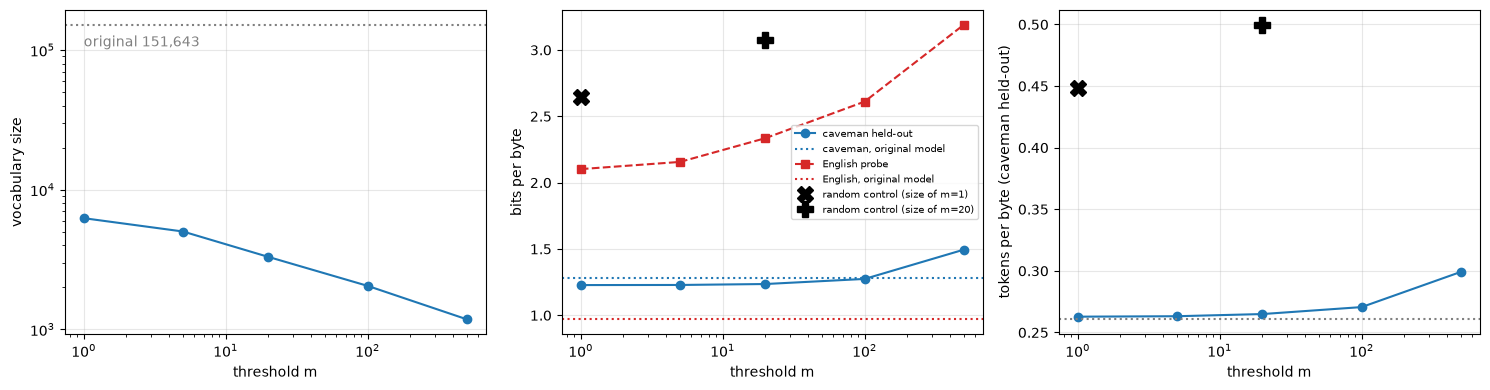

In [13]:
S = [r for r in sweep if "m" in r]
ms = [r["m"] for r in S]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ms, [r["vocab"] for r in S], "o-"); ax[0].set_yscale("log"); ax[0].set_ylabel("vocabulary size")
ax[0].axhline(V, ls=":", c="gray"); ax[0].text(1, V * 0.7, f"original {V:,}", color="gray")
ax[1].plot(ms, [r["bits/byte"] for r in S], "o-", label="caveman held-out")
ax[1].axhline(r0["bits_per_byte"], ls=":", c="C0", label="caveman, original model")
ax[1].plot(ms, [r["English bits/byte"] for r in S], "s--", c="C3", label="English probe")
ax[1].axhline(r0_en["bits_per_byte"], ls=":", c="C3", label="English, original model")
ax[1].set_ylabel("bits per byte"); ax[1].legend(fontsize=8)
ax[2].plot(ms, [r["tokens/byte"] for r in S], "o-"); ax[2].axhline(r0["tokens_per_byte"], ls=":", c="gray")
ax[2].set_ylabel("tokens per byte (caveman held-out)")
for r, mk in zip(control, ["X", "P"]):
    ax[1].plot(r["m"], r["bits/byte"], mk, ms=11, c="k", label=f"random control (size of m={r['m']})")
    ax[2].plot(r["m"], r["tokens/byte"], mk, ms=11, c="k")
ax[1].legend(fontsize=7)
for a in ax:
    a.set_xscale("log"); a.set_xlabel("threshold m"); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig("figures/sweep.png", dpi=150); plt.show()

**Random control.** At the same vocabulary size, random tokens (with their closure) instead of the frequent ones make the
caveman text fall apart into byte-level pieces: the sequence gets several times longer and bits per byte gets much
worse, while frequency-based pruning at the same size costs almost nothing. So the gain is not "a smaller vocabulary is
fine"; it is that the *usage distribution* is extremely skewed and the frequency threshold keeps exactly the part of
the vocabulary the language lives in.

**Knee and what to ship.** Bits per byte stays *below the original* up to m = 100 (vocabulary ≈ 2k: roughly the 961
list words in their one or two spellings, plus punctuation, digits and frequent names) and breaks at m = 500, where list
words start to fall apart (length ratio > 1.15). So the knee of the quality curve is between m = 100 and m = 500.
In *parameters* the knee is already at m = 1: the embedding falls from 27.6% of the model to ~1.6%, and every further
threshold saves at most 1.3% of the model while the held-out agreement and the robustness to unseen names drop fast.
I ship **m = 1**: −26% parameters, the best bits per byte, exactly the original tokenization on everything seen in
training. (For a real language with a long tail of rare words, m ≈ 5 would be the natural compromise.)

In [14]:
SHIP_M = 1
ship = next(r for r in sweep if r.get("m") == SHIP_M)
emb_share = [(r["params (M)"] - (p0 / 1e6 - V_ROWS_ORIG * HIDDEN / 1e6)) / r["params (M)"] for r in S]
print(f"embedding share of all parameters: original {V_ROWS_ORIG * HIDDEN / p0:.1%} -> " +
      ", ".join(f"m={r['m']}: {s:.2%}" for r, s in zip(S, emb_share)))
print(f"ship m={SHIP_M}: vocab {ship['vocab']:,}, params {ship['params (M)']:.1f} M (-{1 - ship['params (M)'] * 1e6 / p0:.1%}), "
      f"bits/byte {ship['bits/byte']:.4f} vs original {r0['bits_per_byte']:.4f}, length ratio {ship['length ratio']:.4f}")
ship_dir = out_dir      # the m = 1 checkpoint saved in Part 3
lap("ship")

embedding share of all parameters: original 27.6% -> m=1: 1.55%, m=5: 1.25%, m=20: 0.83%, m=100: 0.53%, m=500: 0.30%
ship m=1: vocab 6,244, params 363.5 M (-26.4%), bits/byte 1.2279 vs original 1.2846, length ratio 1.0106
[ship: 0 s, total 45 s]


## Bonus B3 — random-init baseline: a new tokenizer trained from scratch
A byte-level BPE trained on the caveman train corpus with the same pre-tokenizer and the same vocabulary size as the
pruned m = 1 tokenizer, plugged into Qwen with (a) random embeddings, (b) each new token initialised as the mean of the
Qwen embeddings of its pieces (Fast Vocabulary Transfer, Gee et al. 2022) — no training in either case.

In [15]:
def train_bpe(vocab_size):
    t = Tokenizer(models.BPE())
    t.normalizer, t.pre_tokenizer, t.decoder = tok.normalizer, tok.pre_tokenizer, tok.decoder
    tr = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=["<|endoftext|>"], show_progress=False,
                             initial_alphabet=[id2tok[i] for i in sorted(base)])
    t.train_from_iterator(train_docs, tr)
    return t

if BONUS:
    seed_all()
    target = new_tok.get_vocab_size(with_added_tokens=True)
    scratch = train_bpe(target)
    sv = scratch.get_vocab()
    overlap = len(set(sv) & set(new_json["model"]["vocab"]))
    print(f"scratch BPE: {len(sv):,} tokens, {overlap:,} shared with the pruned Qwen vocabulary; "
          f"held-out tokens/byte {token_usage(scratch, held_docs)[1] / mb(held_docs) / 1e6:.4f} vs pruned {r1['tokens_per_byte']:.4f}")
    b3 = {}
    for init in ["random", "mean of Qwen pieces"]:
        m = load_model(); emb = m.get_input_embeddings().weight.data
        padded = int(math.ceil(len(sv) / 64) * 64)
        if init == "random":
            new_w = torch.randn(padded, emb.shape[1], generator=torch.Generator().manual_seed(SEED)).to(emb) * emb.float().std().item()
        else:
            new_w = emb.new_zeros(padded, emb.shape[1])
            for t, i in sv.items():
                ids = [eos_old] if t == "<|endoftext|>" else [x.id for x in tok.model.tokenize(t)]
                new_w[i] = emb[ids].float().mean(0).to(emb.dtype)
        m.set_input_embeddings(torch.nn.Embedding(padded, emb.shape[1])); m.get_input_embeddings().weight.data = new_w
        m.get_output_embeddings().weight = m.get_input_embeddings().weight; m.config.vocab_size = padded
        fs = PreTrainedTokenizerFast(tokenizer_object=scratch, eos_token="<|endoftext|>", pad_token="<|endoftext|>")
        m.generation_config.eos_token_id = m.generation_config.bos_token_id = sv["<|endoftext|>"]
        b3[init] = {"bits/byte": bpb(m, scratch, held_docs, sv["<|endoftext|>"])["bits_per_byte"], "gen": generate(m, fs, PROMPTS[:1], 20)[0]}
        print(f"{init:>20}: bits/byte {b3[init]['bits/byte']:.3f} | {b3[init]['gen']!r}")
        del m; torch.cuda.empty_cache()
    print(f"{'pruned Qwen (m=1)':>20}: bits/byte {r1['bits_per_byte']:.3f} | uniform over {len(sv):,} tokens would be "
          f"{math.log2(len(sv)) * token_usage(scratch, held_docs)[1] / (mb(held_docs) * 1e6):.3f}")
    RESULTS["B3"] = b3
    lap("B3")

scratch BPE: 6,266 tokens, 3,675 shared with the pruned Qwen vocabulary; held-out tokens/byte 0.2635 vs pruned 0.2628


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21369.81it/s]

              random: bits/byte 4.719 | 'mammoth be big animal with long hair. peopleoevabalbalbalbalbalbalbalbalbalbalbalbalbalbalbalbalbalbalbal'


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21021.90it/s]

 mean of Qwen pieces: bits/byte 1.232 | 'mammoth be big animal with long hair. people call it a lion. it can run very fast. it can jump very high. it can swim'
   pruned Qwen (m=1): bits/byte 1.228 | uniform over 6,266 tokens would be 3.323
[B3: 5 s, total 50 s]


The new tokenizer is as good as the pruned one *as a tokenizer* (same tokens per byte), but the model does not know its
ids: with random embeddings bits per byte is worse than a uniform guess and generation collapses into one repeated
token. Most new tokens are also Qwen tokens or short sequences of them, so the mean of their Qwen pieces is almost
the right embedding — this "fast vocabulary transfer" initialisation recovers nearly all of the pruned model's quality
without any training. The pruned vocabulary is still preferable: it keeps the exact original embeddings.

## Bonus B1 — vocabulary extension
The reverse direction: new BPE merges trained on the caveman corpus with `tokenizers` (same pre-tokenizer), appended
after the pruned m = 1 vocabulary. A merge is added if both inputs are already tokens and the result is not; it goes to
the end of the merge list, so it only fires on what the old merges leave in pieces. New embeddings = mean of the
embeddings of the pieces. Then a short embedding-only fine-tune (the transformer is frozen) for both the plain pruned
model and the extended one, to separate "more tokens" from "trained on caveman text".

In [16]:
def adjacent_pairs(t):
    """How often two tokens stand next to each other inside one pre-token of the train corpus under tokenizer `t`."""
    words = collections.Counter(w for d in train_docs for w, _ in t.pre_tokenizer.pre_tokenize_str(d))
    pc = collections.Counter()
    for w, n in words.items():
        p = [x.value for x in t.model.tokenize(w)]
        for a, b in zip(p, p[1:]):
            pc[(a, b)] += n
    return pc

def extend(nj, n_new, big, pc):
    """Add the n_new merges of the newly trained BPE whose two inputs most often stand next to each other in the
    current tokenization (a merge whose inputs never meet would add a token that is never used)."""
    nj = json.loads(json.dumps(nj)); vb = nj["model"]["vocab"]
    next_id = max([*vb.values(), *(a["id"] for a in nj["added_tokens"])]) + 1
    cand = sorted({(a, b) for a, b in merges_as_pairs(big) if a in vb and b in vb and a + b not in vb and pc[(a, b)] > 0},
                  key=lambda ab: -pc[ab])
    new = []
    for a, b in cand[:n_new]:
        if True:
            vb[a + b] = next_id; next_id += 1
            nj["model"]["merges"].append(f"{a} {b}" if isinstance(nj["model"]["merges"][0], str) else [a, b])
            new.append((a + b, a, b))
    return nj, new

def finetune_embeddings(m, t, eos, steps, lr=1e-3, bs=8, L=512, scale=1024.0):
    """Train only the (tied) embedding matrix on caveman train text; the transformer stays frozen.
    The optimizer keeps a float32 master copy (AdamW on fp16/bf16 weights loses the updates or produces NaN) and the
    loss is scaled so that fp16 gradients do not underflow; steps with non-finite gradients are skipped."""
    ids = [i for enc in t.encode_batch(train_docs) for i in [eos] + enc.ids]
    for p_ in m.parameters():
        p_.requires_grad_(False)
    w = m.get_input_embeddings().weight; w.requires_grad_(True)
    master = w.detach().float().clone().requires_grad_(True)
    opt = torch.optim.AdamW([master], lr=lr, weight_decay=0.0)
    g = torch.Generator().manual_seed(SEED); m.train(); skipped = 0
    for s in range(steps):
        starts = torch.randint(0, len(ids) - L - 1, (bs,), generator=g)
        x = torch.tensor([ids[i:i + L] for i in starts.tolist()], device=DEVICE)
        loss = F.cross_entropy(m(input_ids=x).logits[:, :-1].float().reshape(-1, w.shape[0]), x[:, 1:].reshape(-1))
        (loss * scale).backward()
        grad = w.grad.float() / scale; w.grad = None
        if not torch.isfinite(grad).all():
            skipped += 1; continue
        master.grad = grad; opt.step(); opt.zero_grad(set_to_none=True)
        w.data.copy_(master.detach().to(w.dtype))
    m.eval(); w.requires_grad_(False)
    return loss.item(), skipped

if BONUS:
    seed_all()
    big = json.loads(train_bpe(16_000).to_str())["model"]
    pc = adjacent_pairs(new_tok)
    print(f"pre-tokens of the train corpus that the pruned tokenizer splits: {sum(pc.values()):,} adjacent token pairs")
    b1, FT_STEPS = [], 100 if DEVICE == "cuda" else 0
    for n_new in [0, 100, 500]:
        nj, new = extend(new_json, n_new, big, pc)
        nt = tokenizer_from_json(nj)
        m = load_model(); prune_model_embeddings(m, old2new); remap_special_ids(m, old2new)
        emb = m.get_input_embeddings().weight.data
        size = max(nj["model"]["vocab"].values()) + 1
        padded = int(math.ceil(max(size, emb.shape[0]) / 64) * 64)
        w = emb.new_zeros(padded, emb.shape[1]); w[:emb.shape[0]] = emb
        for t, a, b in new:
            w[nj["model"]["vocab"][t]] = emb[[x.id for x in new_tok.model.tokenize(t)]].float().mean(0).to(emb.dtype)
        m.set_input_embeddings(torch.nn.Embedding(padded, emb.shape[1])); m.get_input_embeddings().weight.data = w
        m.get_output_embeddings().weight = m.get_input_embeddings().weight; m.config.vocab_size = padded
        _, nt_tok, nt_bytes = token_usage(nt, train_docs)
        row = {"new tokens": len(new), "examples": ", ".join(show(t) for t, _, _ in new[:8]),
               "fertility (train)": nt_tok / n_words, "tokens/byte (held)": None,
               "bits/byte (held)": None, "bits/byte after emb. fine-tune": None}
        r = bpb(m, nt, held_docs, eos_new); row["tokens/byte (held)"] = r["tokens_per_byte"]; row["bits/byte (held)"] = r["bits_per_byte"]
        if FT_STEPS:
            finetune_embeddings(m, nt, eos_new, FT_STEPS)
            row["bits/byte after emb. fine-tune"] = bpb(m, nt, held_docs, eos_new)["bits_per_byte"]
        b1.append(row); print(row)
        del m; torch.cuda.empty_cache()
    tb1 = pd.DataFrame(b1).set_index("new tokens")
    display(tb1.style.format({c: "{:.4f}" for c in tb1.columns if c != "examples"}))
    RESULTS["B1"] = b1
    lap("B1")

pre-tokens of the train corpus that the pruned tokenizer splits: 33,444 adjacent token pairs


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 22774.64it/s]

{'new tokens': 0, 'examples': '', 'fertility (train)': 1.288944143639177, 'tokens/byte (held)': 0.2628227767631003, 'bits/byte (held)': 1.2278778841253932, 'bits/byte after emb. fine-tune': 1.1929444667285372}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 19625.17it/s]

{'new tokens': 500, 'examples': '␣Gowa, atchez, inteler, ruze, ␣Cus, ␣Neculu, ␣Wint, ␣Assam', 'fertility (train)': 1.2840961367479031, 'tokens/byte (held)': 0.26271304023168285, 'bits/byte (held)': 1.229934208930489, 'bits/byte after emb. fine-tune': 1.1836643933583852}


,examples,fertility (train),tokens/byte (held),bits/byte (held),bits/byte after emb. fine-tune
new tokens,,,,,
0,,1.2889,0.2628,1.2279,1.1929
100,"␣Gowa, atchez, inteler, ruze, ␣Cus, ␣Neculu, ␣Wint, ␣Assam",1.2865,0.2628,1.2287,1.1945
500,"␣Gowa, atchez, inteler, ruze, ␣Cus, ␣Neculu, ␣Wint, ␣Assam",1.2841,0.2627,1.2299,1.1837


[B1: 40 s, total 89 s]


Little room is left for extension: every list word is already a single token, digits are split one by one by the
pre-tokenizer, and only rare names (`␣Assam`, `␣Gowa`, …) are split. Fertility improves by well under 1%, and the
mean-initialised new tokens cost a little bits per byte (they compete with the old way of spelling the same string)
until they are trained. The embedding-only fine-tune helps every variant by about the same amount: it teaches the
model the caveman *style*, which matters far more than a few more tokens.

## Bonus B4 — serving: decode throughput and peak memory

In [17]:
@torch.no_grad()
def serve(model_dir, batch, new_tokens=128, reps=2):
    m = AutoModelForCausalLM.from_pretrained(model_dir, dtype=DTYPE).to(DEVICE).eval()
    f = PreTrainedTokenizerFast.from_pretrained(model_dir); f.padding_side = "left"
    x = f([PROMPTS[i % len(PROMPTS)] for i in range(batch)], return_tensors="pt", padding=True).to(DEVICE)
    kw = dict(max_new_tokens=new_tokens, min_new_tokens=new_tokens, do_sample=False, pad_token_id=f.pad_token_id)
    m.generate(**x, max_new_tokens=8, min_new_tokens=8, do_sample=False, pad_token_id=f.pad_token_id)   # warm-up
    if DEVICE == "cuda":
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    for _ in range(reps):
        m.generate(**x, **kw)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = (time.time() - t0) / reps
    peak = torch.cuda.max_memory_allocated() / 2**20 if DEVICE == "cuda" else float("nan")
    del m; torch.cuda.empty_cache()
    return {"tokens/s": batch * new_tokens / dt, "ms/step": dt / new_tokens * 1e3, "peak MiB": peak}

if BONUS:
    b4 = []
    for d, label in dict.fromkeys([("ckpt_original", "original"), (out_dir, f"pruned m={M}"), (ship_dir, f"pruned m={SHIP_M}")]):
        for b in [1, 8]:
            b4.append({"model": label, "batch": b, **serve(d, b)}); print(b4[-1])
    tb4 = pd.DataFrame(b4).set_index(["model", "batch"])
    display(tb4.style.format("{:.1f}"))
    RESULTS["B4"] = b4
    lap("B4")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 19626.12it/s]

{'model': 'original', 'batch': 1, 'tokens/s': 167.7879687726828, 'ms/step': 5.959902890026569, 'peak MiB': 1002.09423828125}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21202.55it/s]

...

{'model': 'pruned m=1', 'batch': 1, 'tokens/s': 170.65456899996218, 'ms/step': 5.8597903698682785, 'peak MiB': 746.978515625}


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 21460.30it/s]

{'model': 'pruned m=1', 'batch': 8, 'tokens/s': 1106.0841390060903, 'ms/step': 7.2327228263020515, 'peak MiB': 762.36865234375}


[B4: 8 s, total 98 s]


The pruned model needs ~25% less GPU memory (the 151,936 × 896 embedding is 27% of the weights). Decode throughput
barely changes on a GPU: generating with a 0.5B model is dominated by 24 transformer layers and kernel-launch overhead,
not by the output head. On a CPU or a phone, where the head's matrix-vector product is a real share of the time, the gain is larger.

## Bonus B2 — Gemma-3-270M: a SentencePiece-style BPE with `byte_fallback`
`google/gemma-3-270m` has a 262,144-token vocabulary on a 268 M-parameter model: the embedding is 63% of all weights.
Its tokenizer is not byte-level: spaces become `▁`, there is no pre-tokenizer, and a character that is not in the
vocabulary falls back to its UTF-8 bytes `<0x00>`…`<0xFF>`. Three things change in the pruning:

1. **Base alphabet.** "Every entry no merge produces" is 25,805 tokens here — single characters of all scripts. With
   byte fallback only the 256 byte tokens are needed for any text to round-trip; unused characters can go.
2. **Duplicate merge results.** 278k of the 515k merges build a token that another merge also builds (an artefact of the
   SentencePiece → BPE conversion), so "the merge that produces t" is not unique. The closure must follow **all** of
   them; following only the highest-priority one breaks check (2), shown below.
3. **Added tokens.** 6,415 added tokens, of which 6,242 are `<unusedN>` placeholders that no text can contain. The
   assignment says to keep added / special tokens; I keep the 7 real specials and 166 whitespace tokens and drop the
   placeholders (both variants are reported).

The model side needs care too: Gemma multiplies the embedding by √640 inside its own embedding module, so the rows are
sliced *in place* instead of swapping in a plain `nn.Embedding` (which the starter's helper would do, silently dropping
the scale). The tokenizer adds `<bos>` by itself, so usage counts and bits per byte use `add_special_tokens=False`
with `<bos>` as the explicit prefix. The model is gated: accept the licence on its Hub page and log in, otherwise this
section is skipped.

In [18]:
def prune_byte_fallback(tok_json, keep_ids, closure="all", keep_unused=False, keep_chars=False, verbose=True):
    """Pruning for a SentencePiece-style BPE with byte_fallback (Gemma 3).
    Differences from the byte-level case:
      * base alphabet = the 256 <0xNN> byte tokens (any character missing from the vocabulary falls back to its UTF-8
        bytes), not every merge-less entry (Gemma has 25.8k of them: single characters of all scripts);
        keep_chars=True keeps all of them instead (the starter's rule);
      * merges have duplicate results (the same token can be built by several merges): closure="all" keeps the inputs
        of every merge that produces a kept token, closure="first" only those of the highest-priority one;
      * added tokens: all of them, or (keep_unused=False) all except the 6,242 `<unusedN>` placeholders."""
    model = tok_json["model"]; vocab = model["vocab"]; id2tok = {i: t for t, i in vocab.items()}
    pairs = [tuple(m) if not isinstance(m, str) else tuple(m.split(" ", 1)) for m in model["merges"]]
    producers = collections.defaultdict(list)
    for a, b in pairs:
        producers[a + b].append((a, b))
    added = [a for a in tok_json["added_tokens"] if keep_unused or not a["content"].startswith("<unused")]
    keep = {id2tok[i] for i in keep_ids if i in id2tok}
    keep |= {a["content"] for a in added if a["content"] in vocab}
    keep |= {t for t in vocab if re.fullmatch(r"<0x[0-9A-F]{2}>", t)}
    if model.get("unk_token"):
        keep.add(model["unk_token"])
    if keep_chars:
        keep |= {t for t in vocab if t not in producers}
    stack = list(keep)
    while stack:
        t = stack.pop()
        for a, b in (producers.get(t, []) if closure == "all" else producers.get(t, [])[:1]):
            for part in (a, b):
                if part not in keep:
                    keep.add(part); stack.append(part)
    old = sorted(vocab[t] for t in keep)
    old2new = {o: n for n, o in enumerate(old)}
    nv = {id2tok[o]: n for o, n in old2new.items()}
    str_fmt = isinstance(model["merges"][0], str)
    nm = [f"{a} {b}" if str_fmt else [a, b] for a, b in pairs if a in nv and b in nv and a + b in nv]
    nj = json.loads(json.dumps(tok_json))
    nj["model"]["vocab"], nj["model"]["merges"] = nv, nm
    nxt, na = len(nv), []
    for at in sorted(added, key=lambda a: a["id"]):
        at = dict(at)
        if at["content"] in nv:
            old2new[at["id"]] = at["id"] = nv[at["content"]]
        else:
            old2new[at["id"]] = at["id"] = nxt; nxt += 1
        na.append(at)
    nj["added_tokens"] = na
    def remap(pp):
        if isinstance(pp, dict):
            for st in (pp.get("special_tokens") or {}).values() if isinstance(pp.get("special_tokens"), dict) else []:
                if "ids" in st:
                    st["ids"] = [old2new[i] for i in st["ids"]]
            for v in pp.values(): remap(v)
        elif isinstance(pp, list):
            for v in pp: remap(v)
    remap(nj.get("post_processor"))
    if verbose:
        print(f"vocab {len(vocab):,} -> {len(nv):,}; merges {len(pairs):,} -> {len(nm):,}; added {len(tok_json['added_tokens']):,} -> {len(na):,}; total ids {nxt:,}")
    return nj, old2new


def prune_embeddings_inplace(model, old2new, pad_to_multiple_of=64):
    """Slice the rows of the existing (tied) embedding module, keeping the module itself (Gemma scales its output).
    Token ids the original matrix has no row for (Gemma's tokenizer has `<image_soft_token>` = 262,144 for the
    multimodal models; the text-only 270M model has 262,144 rows) get a zero row — they were unusable before as well."""
    n = max(old2new.values()) + 1
    padded = int(math.ceil(n / pad_to_multiple_of) * pad_to_multiple_of)
    emb = model.get_input_embeddings()
    old_rows = emb.weight.shape[0]
    index = torch.tensor([o for o, _ in sorted(old2new.items(), key=lambda kv: kv[1])])
    valid = index < old_rows
    w = emb.weight.data.new_zeros(padded, emb.weight.shape[1])
    w[:n][valid.to(w.device)] = emb.weight.data[index[valid].to(w.device)]
    emb.weight = torch.nn.Parameter(w); emb.num_embeddings = padded
    if emb.padding_idx is not None:
        emb.padding_idx = old2new.get(emb.padding_idx)
    head = model.get_output_embeddings()
    head.weight = emb.weight; head.out_features = padded
    model.config.vocab_size = padded
    return model

GEMMA = "google/gemma-3-270m"
GDTYPE = torch.bfloat16 if DEVICE == "cuda" and torch.cuda.get_device_capability()[0] >= 8 else torch.float32  # Gemma overflows in fp16
gpath = None
if BONUS:
    for local_only in (False, True):
        try:
            gpath = snapshot_download(GEMMA, allow_patterns=["*.json", "*.safetensors"], local_files_only=local_only); break
        except Exception as e:
            err = e
    if gpath is None:
        print(f"B2 skipped: {GEMMA} is gated — accept its licence on the Hub and log in ({type(err).__name__})")

if gpath:
    g_json = load_tokenizer_json(os.path.join(gpath, "tokenizer.json"))
    g_tok = tokenizer_from_json(g_json)
    gV = len(g_json["model"]["vocab"])
    g_counts = collections.Counter(i for e in g_tok.encode_batch(train_docs, add_special_tokens=False) for i in e.ids)
    g_nt = sum(g_counts.values())
    print(f"Gemma-3 vocab {gV:,} | train tokens {g_nt:,} | bytes/token {n_bytes / g_nt:.2f} | fertility {g_nt / n_words:.3f} | "
          f"distinct ids {len(g_counts):,} ({len(g_counts) / gV:.2%})")
    g_bos = g_tok.token_to_id("<bos>")
    gm = AutoModelForCausalLM.from_pretrained(gpath, dtype=GDTYPE).to(DEVICE)
    gp0 = n_params(gm)
    g_r0, g_r0_en = bpb(gm, g_tok, held_docs, g_bos), bpb(gm, g_tok, en_probe, g_bos)
    g_fast0 = PreTrainedTokenizerFast(tokenizer_object=g_tok, bos_token="<bos>", eos_token="<eos>", pad_token="<pad>", unk_token="<unk>")
    g_gen0 = generate(gm, g_fast0, PROMPTS[:2])
    gm.to(torch.bfloat16).save_pretrained("gemma_original"); gm.to(GDTYPE); g_size0 = dir_mb("gemma_original")
    del gm; torch.cuda.empty_cache()

    variants = [("starter rule: every merge-less entry + all added", dict(keep_chars=True, keep_unused=True)),
                ("256 byte tokens + all added", dict(keep_unused=True)),
                ("256 byte tokens, no <unused> (shipped)", dict()),
                ("same, closure via first producer only", dict(closure="first"))]
    g_rows = []
    for label, kw in variants:
        nj, o2n = prune_byte_fallback(g_json, list(g_counts), verbose=False, **kw)
        nt = tokenizer_from_json(nj)
        rt = all(nt.decode(nt.encode(d).ids) == d for d in held_docs) and all(nt.decode(nt.encode(d).ids) == d for d in held_en)
        g_rows.append({"variant": label, "vocab": len(nj["model"]["vocab"]), "merges": len(nj["model"]["merges"]),
                       "added": len(nj["added_tokens"]), "round trip": rt,
                       "train identical": agreement(g_tok, nt, train_docs)["identical_fraction"],
                       "held identical": agreement(g_tok, nt, held_docs)["identical_fraction"],
                       "held length ratio": agreement(g_tok, nt, held_docs)["length_ratio"]})
        if label.endswith("(shipped)"):
            g_json1, g_o2n1, g_tok1 = nj, o2n, nt
    tg = pd.DataFrame(g_rows).set_index("variant")
    display(tg.style.format({"vocab": "{:,}", "merges": "{:,}", "added": "{:,}", "train identical": "{:.1%}",
                             "held identical": "{:.1%}", "held length ratio": "{:.4f}"}))

    gm = AutoModelForCausalLM.from_pretrained(gpath, dtype=GDTYPE).to(DEVICE)
    prune_embeddings_inplace(gm, g_o2n1); remap_special_ids(gm, g_o2n1)
    gp1 = n_params(gm)
    g_bos1 = g_o2n1[g_bos]
    g_r1, g_r1_en = bpb(gm, g_tok1, held_docs, g_bos1), bpb(gm, g_tok1, en_probe, g_bos1)
    g_fast1 = PreTrainedTokenizerFast(tokenizer_object=g_tok1, bos_token="<bos>", eos_token="<eos>", pad_token="<pad>", unk_token="<unk>")
    g_gen1 = generate(gm, g_fast1, PROMPTS[:2])
    g_dir = "gemma-3-270m-caveman-m1"
    gm.to(torch.bfloat16).save_pretrained(g_dir); g_fast1.save_pretrained(g_dir); g_size1 = dir_mb(g_dir)
    del gm; torch.cuda.empty_cache()
    gm = AutoModelForCausalLM.from_pretrained(g_dir, dtype=GDTYPE).to(DEVICE)
    g_fr = PreTrainedTokenizerFast.from_pretrained(g_dir)
    g_r1r = bpb(gm, g_fr.backend_tokenizer, held_docs, g_fr.convert_tokens_to_ids("<bos>"))
    assert abs(g_r1r["bits_per_byte"] - g_r1["bits_per_byte"]) < 1e-3
    del gm; torch.cuda.empty_cache()

    g_sweep = []
    for m_ in [1, 5, 20, 100, 500]:
        nj, o2n = prune_byte_fallback(g_json, [i for i, c in g_counts.items() if c >= m_], verbose=False)
        nt = tokenizer_from_json(nj)
        gm = AutoModelForCausalLM.from_pretrained(gpath, dtype=GDTYPE).to(DEVICE); prune_embeddings_inplace(gm, o2n)
        r = bpb(gm, nt, held_docs, o2n[g_bos])
        g_sweep.append({"m": m_, "vocab": len(nj["model"]["vocab"]), "params (M)": n_params(gm) / 1e6,
                        "length ratio": agreement(g_tok, nt, held_docs)["length_ratio"], "bits/byte": r["bits_per_byte"]})
        del gm; torch.cuda.empty_cache()
    tgs = pd.DataFrame(g_sweep).set_index("m")

    tg3 = pd.DataFrame([
        {"": "Gemma-3-270M original", "vocab rows": 262_144, "params (M)": gp0 / 1e6, "bf16 checkpoint (MB)": g_size0,
         "bits/byte caveman": g_r0["bits_per_byte"], "bits/byte English probe": g_r0_en["bits_per_byte"]},
        {"": "pruned (shipped variant, m=1)", "vocab rows": max(g_o2n1.values()) + 1, "params (M)": gp1 / 1e6, "bf16 checkpoint (MB)": g_size1,
         "bits/byte caveman": g_r1["bits_per_byte"], "bits/byte English probe": g_r1_en["bits_per_byte"]},
        {"": "pruned, reloaded", "vocab rows": max(g_o2n1.values()) + 1, "params (M)": gp1 / 1e6, "bf16 checkpoint (MB)": g_size1,
         "bits/byte caveman": g_r1r["bits_per_byte"]}]).set_index("")
    display(tg3.style.format("{:,.4f}", subset=["bits/byte caveman", "bits/byte English probe"]).format("{:,.1f}", subset=["params (M)", "bf16 checkpoint (MB)"]))
    display(tgs.style.format({"vocab": "{:,}", "params (M)": "{:.1f}", "length ratio": "{:.4f}", "bits/byte": "{:.4f}"}))
    print(f"Gemma parameters -{1 - gp1 / gp0:.1%}, checkpoint -{1 - g_size1 / g_size0:.1%} (Qwen: -{1 - p1 / p0:.1%})")
    for a_, b_ in zip(g_gen0, g_gen1):
        print(f"\noriginal: {a_!r}\npruned  : {b_!r}")
    RESULTS["B2"] = {"distinct": len(g_counts), "vocab": gV, "fertility": g_nt / n_words, "variants": g_rows,
                     "params": [gp0, gp1], "ckpt_mb": [g_size0, g_size1], "bpb": [g_r0, g_r1, g_r1r], "bpb_en": [g_r0_en, g_r1_en],
                     "sweep": g_sweep, "gen": [g_gen0, g_gen1]}
    lap("B2")

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 2610.49it/s]

Gemma-3 vocab 262,144 | train tokens 2,409,374 | bytes/token 3.81 | fertility 1.309 | distinct ids 5,562 (2.12%)


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 236/236 [00:00<00:00, 24641.67it/s]

...

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 236/236 [00:00<00:00, 15602.04it/s]

,vocab rows,params (M),bf16 checkpoint (MB),bits/byte caveman,bits/byte English probe
,,,,,
Gemma-3-270M original,262144,268.1,536.2,1.5285,1.1661
"pruned (shipped variant, m=1)",12163,108.1,218.2,1.4919,2.7735
"pruned, reloaded",12163,108.1,218.2,1.4919,nan


,vocab,params (M),length ratio,bits/byte
m,,,,
1,"12,162",108.1,1.0118,1.4919
5,"10,524",107.1,1.0129,1.4925
20,"7,663",105.2,1.0185,1.4976
100,"5,235",103.7,1.0334,1.5384
500,"3,047",102.3,1.1178,1.8110


Gemma parameters -59.7%, checkpoint -59.3% (Qwen: -26.4%)

original: 'mammoth be big animal with long hair. people are very fond of it.<start_of_image>The first thing that comes to mind is the big wolf.<start_of_image>The wolf is a big animal with long hair.'
pruned  : 'mammoth be big animal with long hair. people who live in the forest have a big house.<start_of_image>The house is big and the house is big.<start_of_image>The house is big and the house is'

original: 'long ago, people of Rome make a habit of going to the temple of the Virgin Mary.\n\nThe Virgin Mary is the patron saint of the Catholic Church.\n\nThe Virgin Mary is'
pruned  : 'long ago, people of Rome make a point of not only writing down the history of the Roman Empire, but also of writing down the history of the people of Rome.\n\nThe Roman'
[B2: 33 s, total 130 s]


With byte fallback the pruned Gemma keeps **all** the guarantees of Part 2 (any text round-trips, the train corpus is
tokenized identically, held-out text almost so) while dropping ~95% of the vocabulary. Because the embedding is 63% of
Gemma's weights, the same procedure that saved 26% on Qwen cuts Gemma by more than half. The starter's "every merge-less
entry" rule would keep 3× more tokens for nothing; the `<unused>` placeholders alone would cost 6k rows; and following
only the first producer of each token is not a valid closure for this tokenizer (check (2) fails).

## Summary and reproducibility

In [19]:
RESULTS["times"] = TIMES
RESULTS["env"] = {"device": torch.cuda.get_device_name() if DEVICE == "cuda" else "cpu", "torch": torch.__version__,
                  "transformers": transformers.__version__, "tokenizers": tokenizers.__version__, "tiktoken": tiktoken.__version__,
                  "seed": SEED, "dtype": str(DTYPE)}
json.dump(RESULTS, open("results.json", "w"), indent=1, default=str)
print(json.dumps(TIMES), f"| total runtime {time.time() - T_START:.0f} s on {RESULTS['env']['device']}")

{"corpus": 0.3, "part1": 2.2, "part2": 2.6, "part3": 12.2, "part4": 27.1, "ship": 0.4, "B3": 5.1, "B1": 39.6, "B4": 8.3, "B2": 32.7} | total runtime 130 s on NVIDIA GeForce RTX 4090
